In [ ]:
import marimo as mo

mo.md(
    """
    # Tabular Regression with ARD on the Diabetes Dataset

    A practical ARD example on scikit-learn's built-in diabetes regression
    dataset. This is a common small regression benchmark that works offline.
    """
)

# Tabular Regression with ARD on the Diabetes Dataset

A practical ARD example on scikit-learn's built-in diabetes regression
dataset. This is a common small regression benchmark that works offline.

[02] Loading scikit-learn diabetes dataset
[02] Prepared split: X_train=(180, 10), X_test=(80, 10), features=10


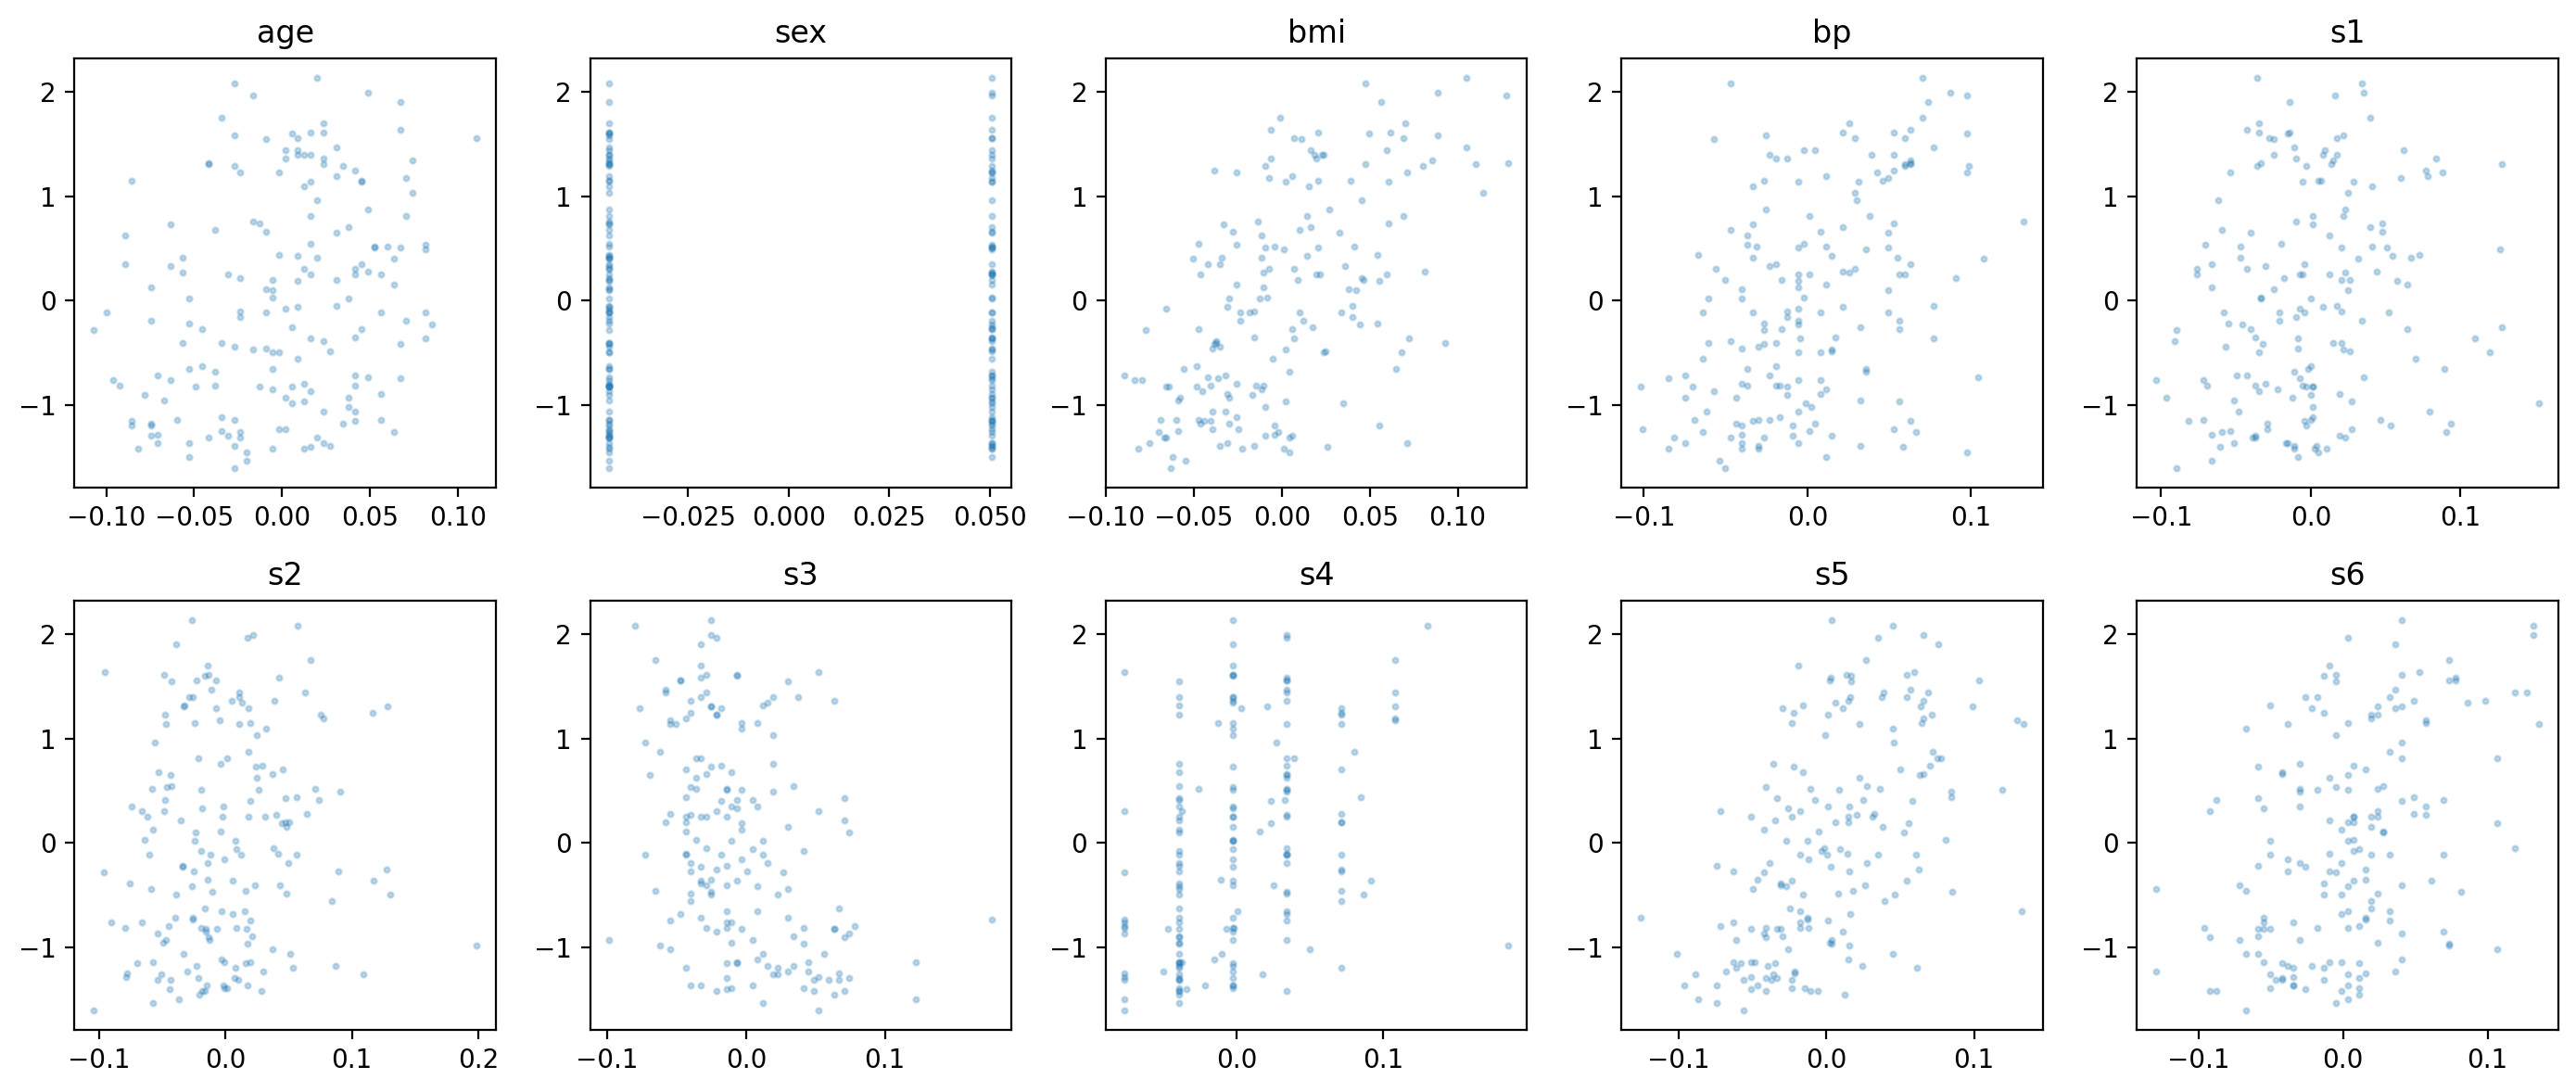

Data Setup 
 
 Dataset: scikit-learn diabetes regression benchmark 
 Training rows: 180 
 Held-out rows: 80 
 Features: 10 
 Target normalization: training rows only
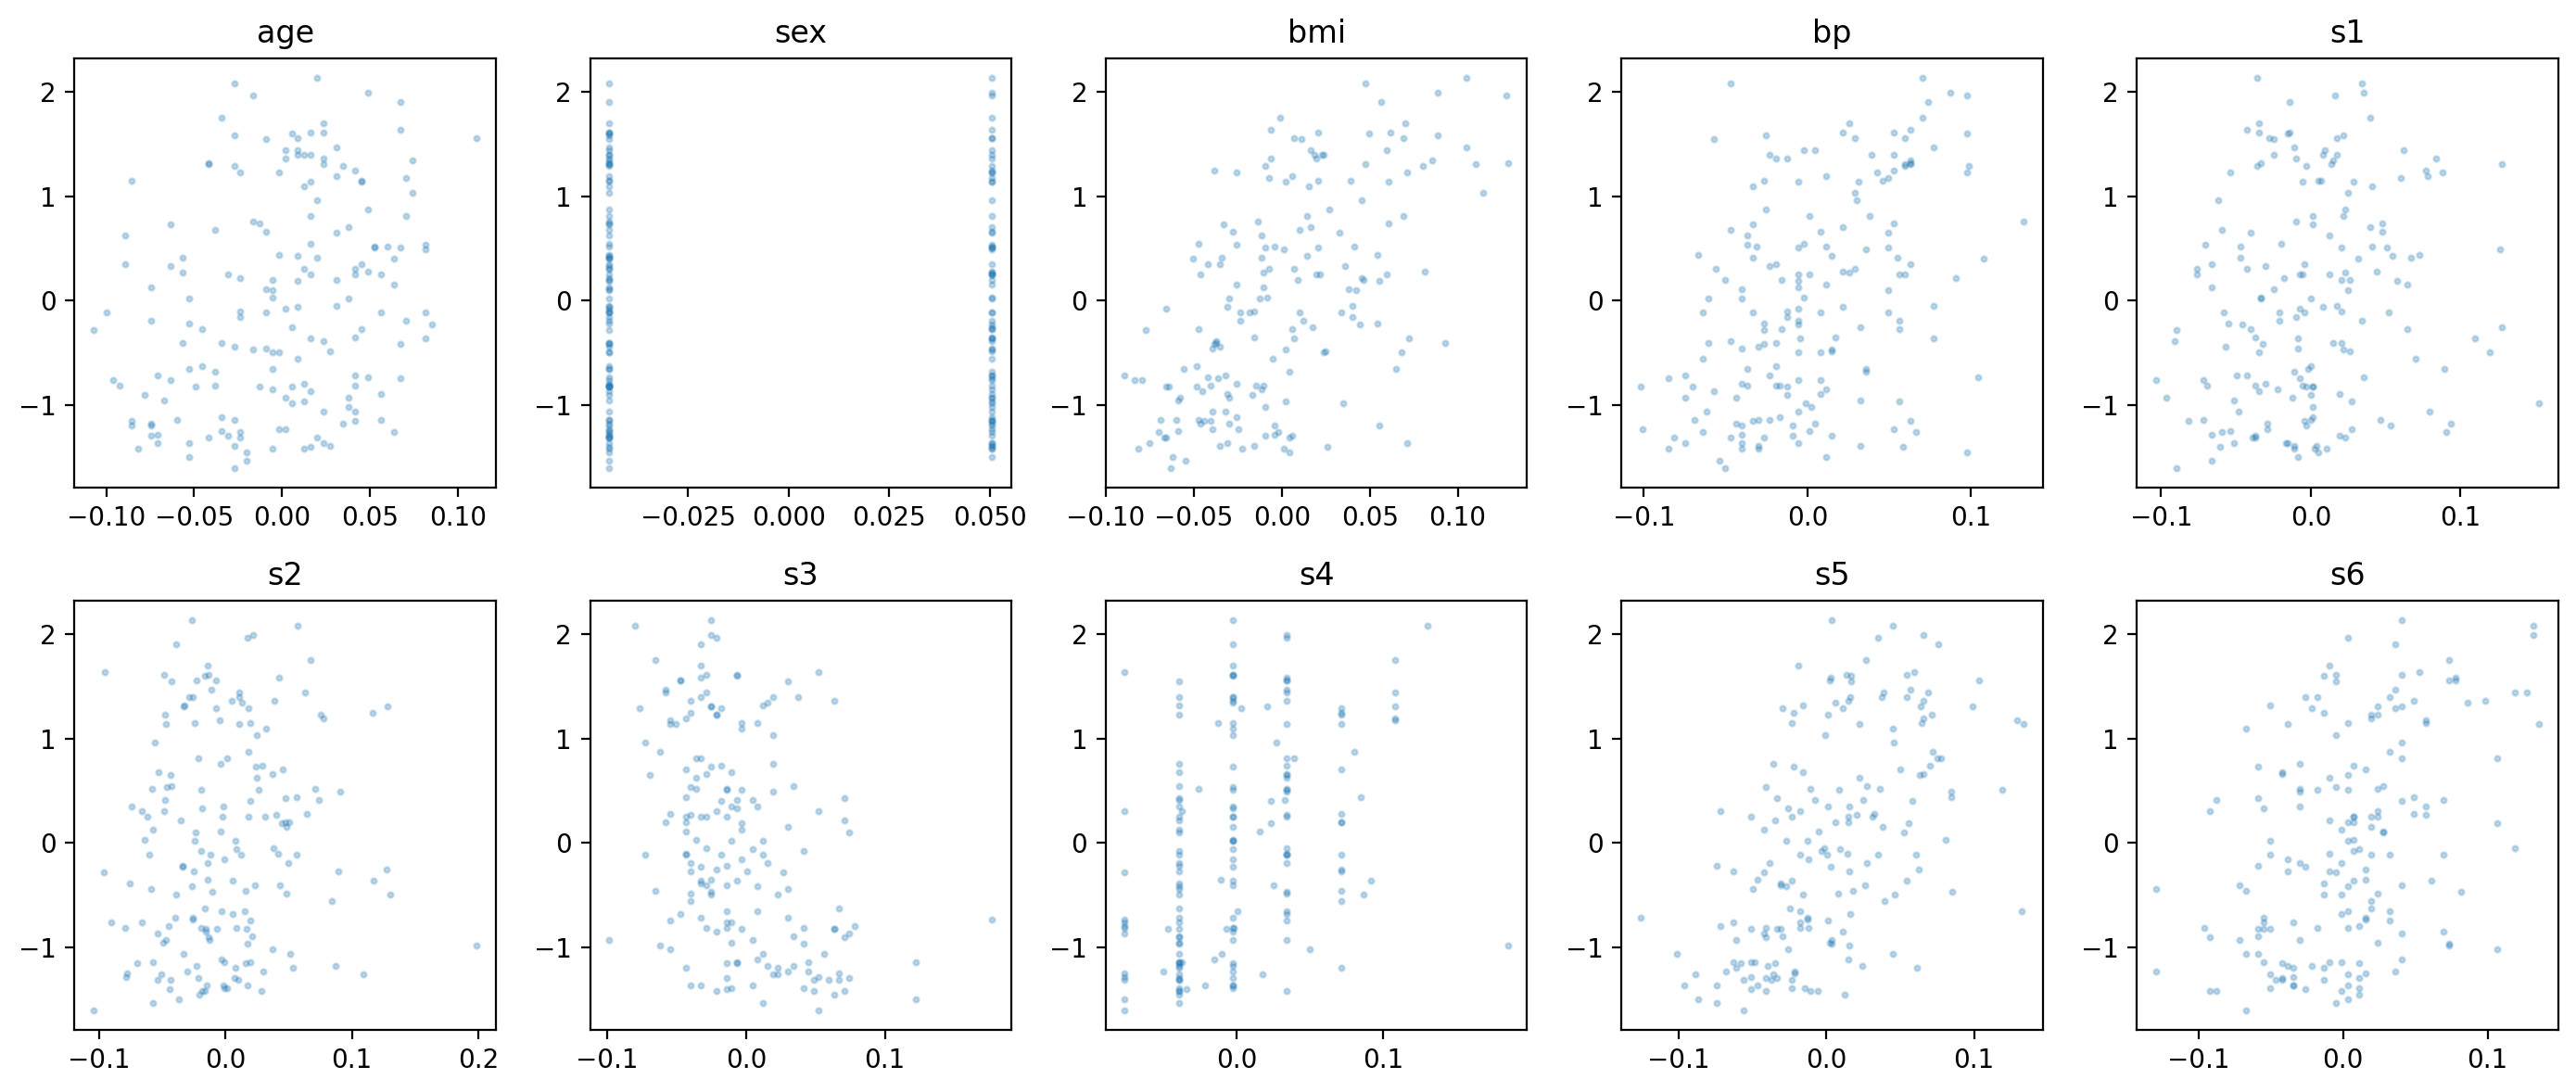

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

print("[02] Loading scikit-learn diabetes dataset")
data = load_diabetes()
feature_names = list(data.feature_names)
X = data.data.astype(np.float32)
y_raw = data.target.astype(np.float32)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X,
    y_raw,
    train_size=180,
    test_size=80,
    random_state=42,
)
y_mean = float(y_train_raw.mean())
y_std = float(y_train_raw.std())
y_train = ((y_train_raw - y_mean) / y_std).astype(np.float32)
y_test = ((y_test_raw - y_mean) / y_std).astype(np.float32)
print(
    f"[02] Prepared split: X_train={X_train.shape}, X_test={X_test.shape}, "
    f"features={len(feature_names)}"
)

fig, feature_axes = plt.subplots(2, 5, figsize=(14, 6))
for i, feature_ax in enumerate(feature_axes.flat):
    feature_ax.scatter(X_train[:, i], y_train, s=4, alpha=0.25)
    feature_ax.set_title(feature_names[i])
fig.tight_layout()
mo.vstack(
    [
        mo.md(
            f"""
            ## Data Setup

            - Dataset: scikit-learn diabetes regression benchmark
            - Training rows: `{len(X_train)}`
            - Held-out rows: `{len(X_test)}`
            - Features: `{len(feature_names)}`
            - Target normalization: training rows only
            """
        ),
        mo.mpl.interactive(fig),
    ]
)

[02] Training SingleOutputGP with an ARD RBF kernel
[02] Predicting on held-out rows
[02] RMSE=0.7431, R2=0.4083, final NLL=1.3899
[02] Shortest ARD lengthscales: s1, sex, s5


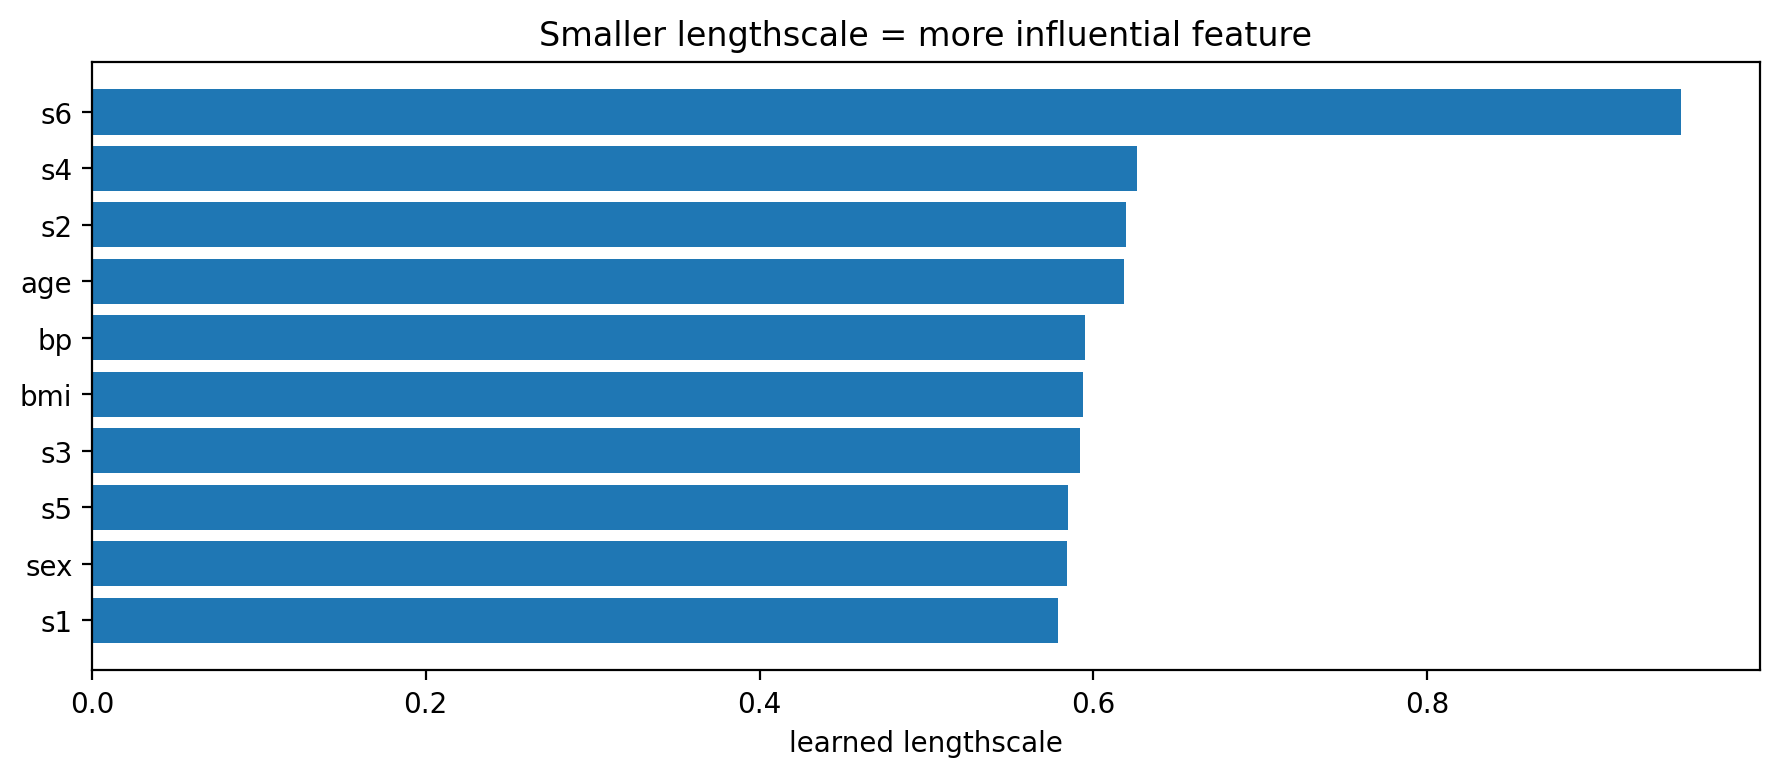

Quantity,Value
RMSE,0.7431
R²,0.4083
Final NLL,1.3899
Noise,0.2037

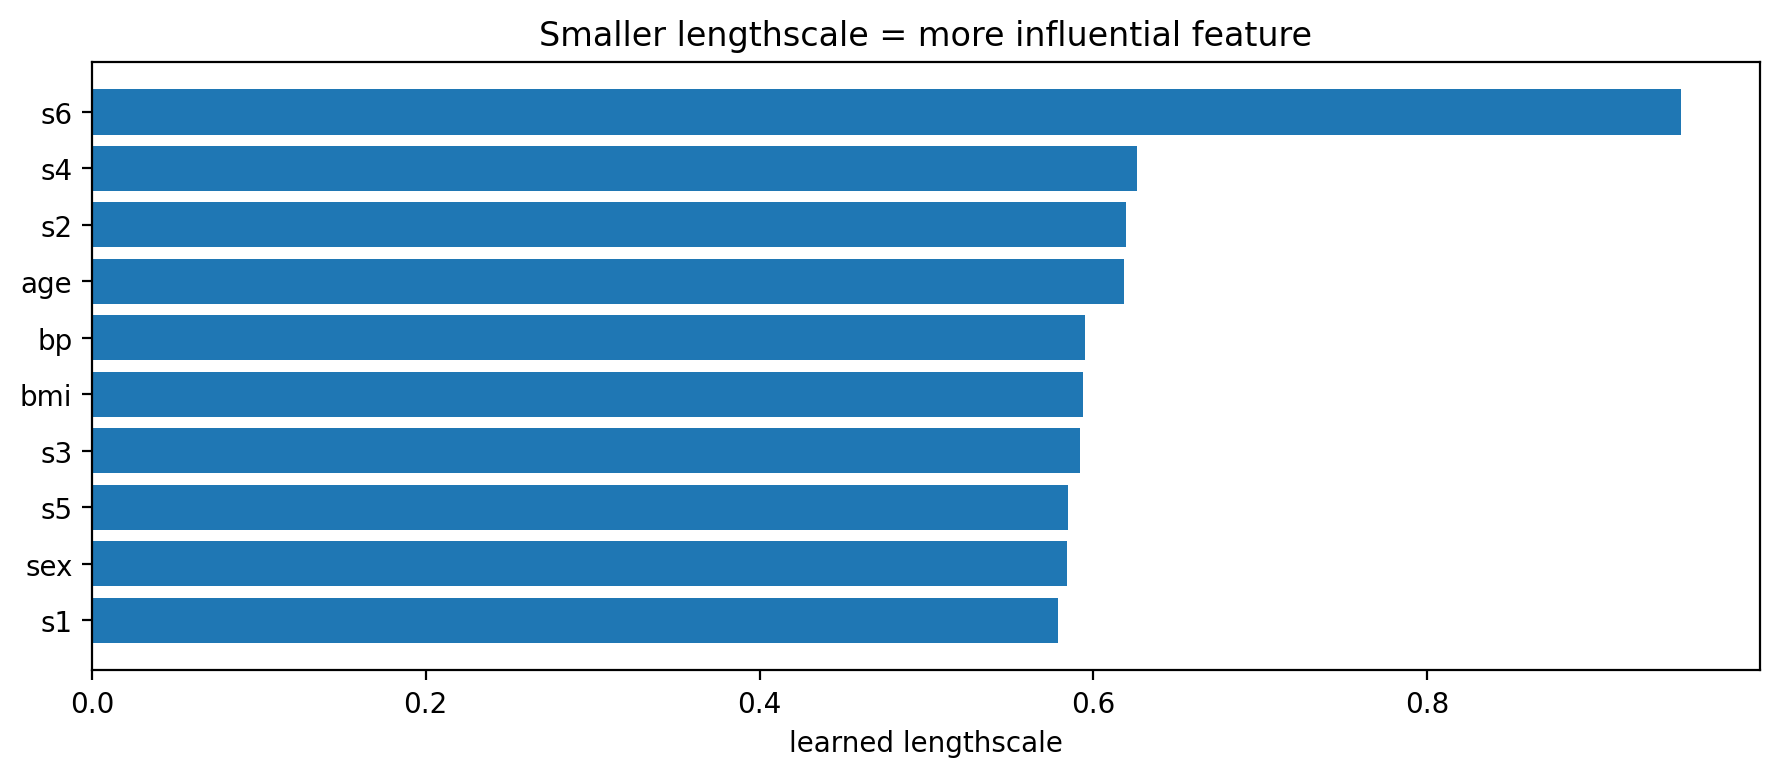

In [ ]:
from mojogp import RBF, SingleOutputGP

print("[02] Training SingleOutputGP with an ARD RBF kernel")
gp = SingleOutputGP(RBF(ard=True, lengthscale=1.0))
train_result = gp.fit(
    X_train,
    y_train,
    max_iterations=25,
    learning_rate=0.035,
    method="materialized",
    progress=True,
)

print("[02] Predicting on held-out rows")
mean, std = gp.predict(X_test, return_std=True, progress=True)
rmse = float(np.sqrt(np.mean((mean - y_test) ** 2)))
r2 = gp.score(X_test, y_test)
print(f"[02] RMSE={rmse:.4f}, R2={r2:.4f}, final NLL={train_result.nll:.4f}")

def ard_pairs(params, names):
    pairs = []
    for param_name, value in params.items():
        if "_ls_" not in param_name and not param_name.startswith("ls_"):
            continue
        feature_idx = int(param_name.split("_")[-1])
        pairs.append((names[feature_idx], value))
    return sorted(pairs, key=lambda item: item[1])

params = gp.get_learned_params()
ls_pairs = ard_pairs(params, feature_names)
top_features = ", ".join(name for name, _ in ls_pairs[:3]) or "n/a"
print(f"[02] Shortest ARD lengthscales: {top_features}")

fig_rank, rank_ax = plt.subplots(figsize=(9, 4))
rank_ax.barh(
    range(len(ls_pairs)),
    [value for _, value in ls_pairs],
    color="tab:blue",
)
rank_ax.set_yticks(range(len(ls_pairs)))
rank_ax.set_yticklabels([name for name, _ in ls_pairs])
rank_ax.set_xlabel("learned lengthscale")
rank_ax.set_title("Smaller lengthscale = more influential feature")
fig_rank.tight_layout()

mo.vstack(
    [
        mo.md(
            f"""
            ## Standard ARD Model

            - Fitted `SingleOutputGP(RBF(ard=True))` with the materialized exact route.
            - Treated all `{X_train.shape[1]}` diabetes columns as continuous inputs.
            - Predicted `{len(X_test)}` held-out rows.
            - Shortest learned lengthscales: `{top_features}`.
            """
        ),
        mo.mpl.interactive(fig_rank),
        mo.md(
            f"""
            ## Fit Summary

            | Quantity | Value |
            |---|---:|
            | RMSE | {rmse:.4f} |
            | R² | {r2:.4f} |
            | Final NLL | {train_result.nll:.4f} |
            | Noise | {params["noise"]:.4f} |

            Shorter learned lengthscales indicate features the GP had to vary more
            aggressively along. On diabetes, the ranking should concentrate on a small
            subset of clinically relevant covariates rather than staying flat.
            """
        ),
    ]
)